# Phase 1: USDCUSDT Peg Analysis

## Why start here?
USDC is a **stablecoin** — it's designed to always trade at exactly **$1.00**. Unlike BTC or ETH where prices swing wildly, any meaningful deviation from $1.00 in USDC is inherently suspicious.

This makes it the **easiest pair to analyze**: we don't need complex baselines or ML models. Simple rules catch real violations.

## What we're looking for:
1. **`peg_break`** — Trades where price deviates >0.5% from $1.00 (i.e., price < $0.995 or > $1.005)
2. **`wash_volume_at_peg`** — Same wallet trading both sides (buy & sell) at exactly $1.00, creating fake volume
3. **`aml_structuring`** — Many near-identical small trades from the same wallet (smurfing)
4. **`wash_trading`** — Same wallet on both sides with near-zero net position

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---------- Load the data ----------
trades = pd.read_csv('student-pack/crypto-trades/USDCUSDT_trades.csv')
market = pd.read_csv('student-pack/crypto-market/Binance_USDCUSDT_2026_minute.csv')

# Parse timestamps
trades['timestamp'] = pd.to_datetime(trades['timestamp'])
trades['date'] = trades['timestamp'].dt.date.astype(str)
market['Date'] = pd.to_datetime(market['Date'])

print(f"Trades: {len(trades)} rows, date range: {trades['timestamp'].min()} to {trades['timestamp'].max()}")
print(f"Market: {len(market)} rows, date range: {market['Date'].min()} to {market['Date'].max()}")
print(f"\nUnique wallets: {trades['trader_id'].nunique()}")
print(f"Price range: {trades['price'].min():.6f} to {trades['price'].max():.6f}")
print(f"\nFirst few trades:")
trades.head(10)

Trades: 1019 rows, date range: 2026-01-01 03:26:52.062612 to 2026-02-28 23:28:07.424509
Market: 110862 rows, date range: 2026-01-01 00:00:00 to 2026-03-18 23:59:00

Unique wallets: 57
Price range: 0.987836 to 1.005697

First few trades:


,trade_id,timestamp,price,quantity,side,trader_id,manager_id,exchange,order_type,fee_rate,settlement_status,venue_code,session_id,latency_ms,region_code,api_version,ip_hash,raw_msg_id,date
0,USDCUSDT_00000385,2026-01-01 03:26:52.062612,1.001244,0.129535,BUY,wallet_USD0027,NaN,BINANCE,MARKET,0.001379,SETTLED,VC836,d0f867951f6b,15,US-EAST,v2.3,a5bb8059,MSG309947489,2026-01-01
1,USDCUSDT_00000393,2026-01-01 05:59:31.772006,1.001229,0.150904,BUY,wallet_USD0008,NaN,BINANCE,MARKET,0.000661,SETTLED,VC426,b9302c247619,175,APAC-SOUTH,v2.3,dd958a50,MSG365289704,2026-01-01
2,USDCUSDT_00000620,2026-01-01 06:59:00.167963,1.001233,0.270043,SELL,wallet_USD0030,NaN,BINANCE,MARKET,0.000714,SETTLED,VC517,187d1e3662c6,278,APAC-SOUTH,v2.3,47d87c7c,MSG470768516,2026-01-01
3,USDCUSDT_00000276,2026-01-01 08:19:49.864895,1.001241,0.664875,SELL,wallet_USD0049,NaN,BINANCE,LIMIT,0.000754,SETTLED,VC486,8a998d14ca48,144,EU-CENTRAL,v3.0,5f50b5e7,MSG779197420,2026-01-01
4,USDCUSDT_00000699,2026-01-01 11:17:17.024306,1.001220,0.307025,SELL,wallet_USD0033,NaN,BINANCE,LIMIT,0.001192,SETTLED,VC514,434428ee58e5,459,EU-CENTRAL,v2.3,62026ea5,MSG190666770,2026-01-01
5,USDCUSDT_00000777,2026-01-01 11:51:24.341279,1.001312,0.425861,SELL,wallet_USD0006,NaN,BINANCE,LIMIT,0.000733,SETTLED,VC892,184cdbb1ea88,25,APAC-SOUTH,v3.0,7b1053ac,MSG423404324,2026-01-01
6,USDCUSDT_00000388,2026-01-01 12:47:38.109184,1.001248,0.744239,SELL,wallet_USD0048,NaN,BINANCE,MARKET,0.001338,SETTLED,VC473,54ac0d317b42,234,APAC-NORTH,v2.3,6cb33272,MSG126572323,2026-01-01
7,USDCUSDT_00000862,2026-01-01 14:42:39.797947,1.001037,0.884375,SELL,wallet_USD0037,NaN,BINANCE,MARKET,0.001316,SETTLED,VC601,8a7302511ff0,80,APAC-SOUTH,v2.3,a0a3a452,MSG444068625,2026-01-01
8,USDCUSDT_00000124,2026-01-01 15:22:49.100042,1.001037,0.049156,SELL,wallet_USD0034,NaN,BINANCE,LIMIT,0.000811,SETTLED,VC111,e9cbcbe6aef8,145,US-EAST,v2.3,2b62f873,MSG981183944,2026-01-01
9,USDCUSDT_00000136,2026-01-01 17:21:42.299703,1.001068,0.131040,SELL,wallet_USD0028,NaN,BINANCE,MARKET,0.000632,SETTLED,VC979,2f81e48eca36,89,APAC-SOUTH,v2.2,d62a4d72,MSG472594865,2026-01-01


## Step 1: Price Distribution — Where does USDC actually trade?

Before flagging anomalies, we need to understand what "normal" looks like. For USDC, normal = very tight cluster around $1.00. Let's visualize the price distribution to see if any outliers jump out.

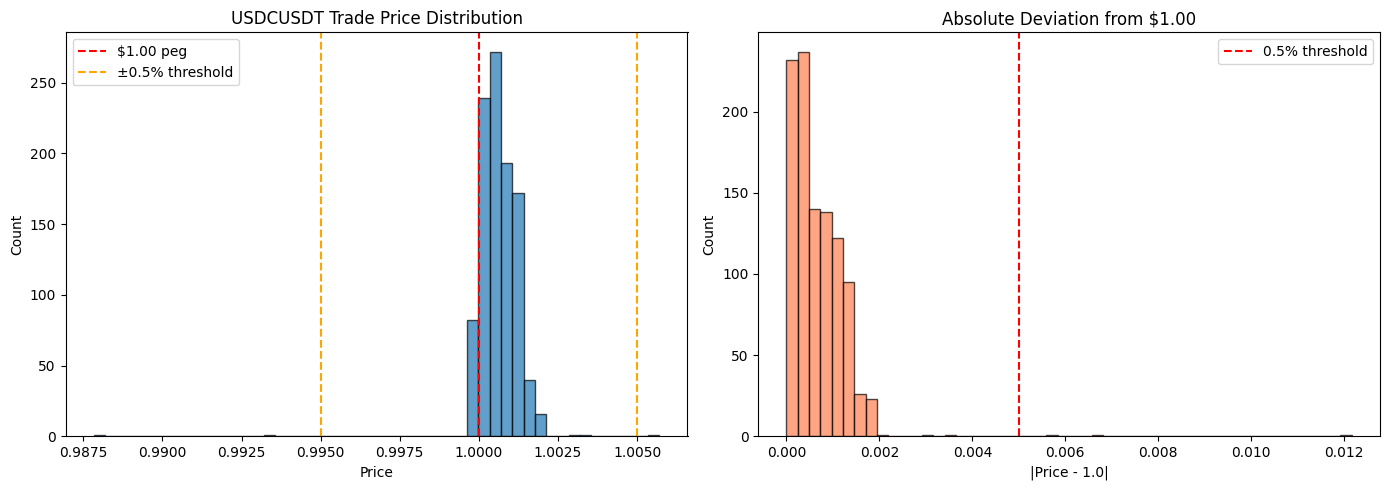

Mean price: 1.000620
Std dev:    0.000697
Median:     1.000559

Trades with |deviation| > 0.5%: 3
Trades with |deviation| > 0.2%: 5
Trades with |deviation| > 0.1%: 266


In [24]:
# --- Price distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(trades['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=1.0, color='red', linestyle='--', label='$1.00 peg')
axes[0].axvline(x=1.005, color='orange', linestyle='--', label='±0.5% threshold')
axes[0].axvline(x=0.995, color='orange', linestyle='--')
axes[0].set_title('USDCUSDT Trade Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')
axes[0].legend()

# Deviation from peg
trades['peg_deviation'] = abs(trades['price'] - 1.0)
axes[1].hist(trades['peg_deviation'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=0.005, color='red', linestyle='--', label='0.5% threshold')
axes[1].set_title('Absolute Deviation from $1.00')
axes[1].set_xlabel('|Price - 1.0|')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Quick stats
print(f"Mean price: {trades['price'].mean():.6f}")
print(f"Std dev:    {trades['price'].std():.6f}")
print(f"Median:     {trades['price'].median():.6f}")
print(f"\nTrades with |deviation| > 0.5%: {(trades['peg_deviation'] > 0.005).sum()}")
print(f"Trades with |deviation| > 0.2%: {(trades['peg_deviation'] > 0.002).sum()}")
print(f"Trades with |deviation| > 0.1%: {(trades['peg_deviation'] > 0.001).sum()}")

## Step 2: Detect Peg Breaks

**What is a peg break?** A stablecoin "breaks its peg" when it trades significantly away from $1.00. This can happen during market stress (legitimate) or be caused by manipulation (suspicious).

The problem statement says flag trades where `abs(price - 1.0) > 0.005` (0.5% deviation). These are our easiest catches.

In [25]:
# --- Detector 1: Peg Breaks ---
# Flag any trade where price deviates more than 0.5% from $1.00
peg_break_mask = trades['peg_deviation'] > 0.005
peg_breaks = trades[peg_break_mask].copy()

print(f"Found {len(peg_breaks)} potential peg break trades\n")

if len(peg_breaks) > 0:
    print(peg_breaks[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id', 'peg_deviation']].to_string(index=False))
else:
    # Try a softer threshold — the problem says >0.5%, but let's see what's at >0.2%
    print("No trades beyond 0.5% — let's check softer thresholds:")
    soft_mask = trades['peg_deviation'] > 0.002
    soft_breaks = trades[soft_mask]
    print(f"\n  >0.2% deviation: {len(soft_breaks)} trades")
    if len(soft_breaks) > 0:
        print(soft_breaks[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id', 'peg_deviation']].to_string(index=False))

Found 3 potential peg break trades

         trade_id           timestamp    price   quantity side trader_id  peg_deviation
USDCUSDT_00001001 2026-01-14 11:39:00 1.005697 268.848994  BUY trader_01       0.005697
USDCUSDT_00001010 2026-02-02 10:48:00 0.993304 126.012590  BUY trader_04       0.006696
USDCUSDT_00001011 2026-02-09 11:01:00 0.987836 198.014104 SELL trader_05       0.012164


## Step 3: Detect Wash Trading at Peg

**What is wash trading?** A trader buys and sells the same asset to themselves, creating artificial volume without any real change in ownership.

**Why our first approach was wrong:** We flagged every wallet that had both BUY and SELL trades. But on a stablecoin traded over 2 months, *of course* most wallets trade both sides — that's normal!

**Better detection — what makes wash trading actually suspicious:**
1. **Temporal clustering** — buy and sell happen within *minutes*, not days apart
2. **Quantity matching** — buy qty ≈ sell qty in the paired trades
3. **Unusual size** — wash trades are often much larger than the wallet's normal activity
4. **Price at exact peg** — for USDC, wash volume specifically at $1.0000

We'll look for **paired trades** from the same wallet: a BUY and SELL close in time with similar quantities.

In [26]:
# --- Detector 2: Wash Trading (Improved) ---
# 
# KEY LESSON: "wallet has both BUY and SELL" is NOT enough.
# Normal traders buy and sell over weeks. Wash traders buy+sell 
# the SAME amount within MINUTES to fake volume.
#
# Strategy: For each wallet, find BUY-SELL pairs that are:
#   - Close in time (within 30 minutes)
#   - Similar in quantity (within 15%)
#   - Unusually large compared to normal USDC trade sizes

# First, let's understand what "normal" looks like
print("=== Normal trade size distribution ===")
print(f"Median quantity: {trades['quantity'].median():.4f}")
print(f"Mean quantity:   {trades['quantity'].mean():.4f}")
print(f"95th percentile: {trades['quantity'].quantile(0.95):.4f}")
print(f"99th percentile: {trades['quantity'].quantile(0.99):.4f}")

# Find rapid buy-sell pairs from same wallet
wash_candidates = []
for wallet in trades['trader_id'].unique():
    wt = trades[trades['trader_id'] == wallet].sort_values('timestamp')
    buys = wt[wt['side'] == 'BUY']
    sells = wt[wt['side'] == 'SELL']
    
    for _, b in buys.iterrows():
        for _, s in sells.iterrows():
            time_diff = abs((b['timestamp'] - s['timestamp']).total_seconds()) / 60
            if time_diff > 30:  # must be within 30 min
                continue
            qty_diff = abs(b['quantity'] - s['quantity']) / max(b['quantity'], s['quantity'])
            if qty_diff > 0.15:  # quantities must be within 15%
                continue
            # Both quantities should be large (above 75th percentile)
            if min(b['quantity'], s['quantity']) < trades['quantity'].quantile(0.75):
                continue
                
            wash_candidates.append({
                'buy_trade_id': b['trade_id'],
                'sell_trade_id': s['trade_id'],
                'wallet': wallet,
                'buy_qty': b['quantity'],
                'sell_qty': s['quantity'],
                'buy_price': b['price'],
                'sell_price': s['price'],
                'time_diff_min': time_diff,
                'qty_match_pct': (1 - qty_diff) * 100,
                'buy_time': b['timestamp'],
                'sell_time': s['timestamp']
            })

wash_df = pd.DataFrame(wash_candidates)
print(f"\n=== Found {len(wash_df)} wash trading pairs ===\n")
if len(wash_df) > 0:
    print(wash_df.to_string(index=False))

=== Normal trade size distribution ===
Median quantity: 0.2220
Mean quantity:   4.0555
95th percentile: 1.0245
99th percentile: 106.6088

=== Found 0 wash trading pairs ===



In [27]:
# Collect wash trade IDs
wash_trade_ids = set()
if len(wash_df) > 0:
    wash_trade_ids = set(wash_df['buy_trade_id']) | set(wash_df['sell_trade_id'])

# Classify: trades at exact peg = wash_volume_at_peg, others = wash_trading
wash_trades = trades[trades['trade_id'].isin(wash_trade_ids)].copy()
if len(wash_trades) > 0:
    wash_trades['violation_type'] = np.where(
        wash_trades['peg_deviation'] < 0.001,  # within 0.1% of peg = "at peg"
        'wash_volume_at_peg',
        'wash_trading'
    )
    print(f"Flagged {len(wash_trades)} individual trades as wash trading\n")
    print(wash_trades[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id', 'violation_type']].to_string(index=False))
else:
    print("No wash trading pairs found with strict criteria.")

No wash trading pairs found with strict criteria.


## Step 4: Detect AML Structuring (Smurfing)

**What is structuring?** It's when someone breaks a large transaction into many smaller ones to avoid detection thresholds. In banking, the threshold is $10,000 (reporting requirement). In crypto, structuring shows up as many near-identical sized trades from the same wallet.

**Detection approach:**
- Group trades by wallet
- Look for wallets with many trades of suspiciously similar quantities (low standard deviation in quantity)
- Especially suspicious if trades happen in a short time window

In [28]:
# --- Detector 3: AML Structuring ---

# Per-wallet quantity analysis
wallet_qty = trades.groupby('trader_id').agg(
    trade_count=('trade_id', 'count'),
    qty_mean=('quantity', 'mean'),
    qty_std=('quantity', 'std'),
    qty_min=('quantity', 'min'),
    qty_max=('quantity', 'max'),
    time_span_hours=('timestamp', lambda x: (x.max() - x.min()).total_seconds() / 3600)
).reset_index()

# Coefficient of variation: std/mean — low CV means suspiciously uniform quantities
wallet_qty['qty_cv'] = wallet_qty['qty_std'] / (wallet_qty['qty_mean'] + 1e-10)

# Structuring signal: multiple trades (>=3) with very low quantity variation
# AND quantities are small (below some threshold)
structuring_wallets = wallet_qty[
    (wallet_qty['trade_count'] >= 3) & 
    (wallet_qty['qty_cv'] < 0.15)  # less than 15% variation in trade sizes
].sort_values('qty_cv')

print("=== Wallets with suspiciously uniform trade sizes (potential structuring) ===\n")
if len(structuring_wallets) > 0:
    print(structuring_wallets.to_string(index=False))
    
    # Show the actual trades for these wallets
    for wallet in structuring_wallets['trader_id']:
        wt = trades[trades['trader_id'] == wallet].sort_values('timestamp')
        print(f"\n--- Trades for {wallet} ---")
        print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
else:
    print("No clear structuring patterns found. Let's check a broader view:")
    print(wallet_qty.sort_values('qty_cv').head(10).to_string(index=False))

=== Wallets with suspiciously uniform trade sizes (potential structuring) ===

trader_id  trade_count  qty_mean  qty_std   qty_min   qty_max  time_span_hours   qty_cv
trader_06            7 90.884956 4.245912 82.783322 94.703603         2.910249 0.046717

--- Trades for trader_06 ---
         trade_id                  timestamp    price  quantity side
USDCUSDT_00001012 2026-02-16 10:56:46.744985 1.000910 87.968893  BUY
USDCUSDT_00001013 2026-02-16 11:02:31.633125 0.999719 93.699429  BUY
USDCUSDT_00001014 2026-02-16 11:22:29.311283 1.000021 94.182438  BUY
USDCUSDT_00001015 2026-02-16 11:36:36.057789 1.000470 94.703603  BUY
USDCUSDT_00001016 2026-02-16 12:30:26.344056 1.003430 82.783322  BUY
USDCUSDT_00001017 2026-02-16 13:50:26.109555 1.003010 91.256560  BUY
USDCUSDT_00001018 2026-02-16 13:51:23.640700 1.000562 91.600449  BUY


## Step 5: Coordinated Structuring & Chain Layering

**Why our first chain layering detector was too loose:** Any two consecutive trades (sell→buy) with vaguely similar quantities within 1 hour got flagged. With ~17 trades/day, random consecutive matches are common.

**Better approach for chain layering (A→B→C):**
- Tighter quantity match (<10% difference)
- Tighter time window (<15 minutes)  
- Quantities should be notably large (above median)
- Look for *chains* of 3+ hops, not just pairs

**For coordinated structuring:** Look for multiple *different* wallets making similar-sized trades in a short burst — organized smurfing.

In [29]:
# --- Detector 4: Chain Layering (Tightened) ---
# Look for sell→buy across different wallets with:
#   - Tight qty match (<10%)
#   - Short time gap (<15 min)
#   - Above-median quantities (filter out trivial noise)

trades_sorted = trades.sort_values('timestamp').reset_index(drop=True)
qty_median = trades['quantity'].median()

chains = []
for i in range(len(trades_sorted) - 1):
    for j in range(i + 1, min(i + 5, len(trades_sorted))):  # check next few trades
        t1 = trades_sorted.iloc[i]
        t2 = trades_sorted.iloc[j]
        
        time_gap = (t2['timestamp'] - t1['timestamp']).total_seconds() / 60
        if time_gap > 15:  # strict: within 15 minutes
            break
            
        if (t1['trader_id'] != t2['trader_id'] and 
            t1['side'] == 'SELL' and t2['side'] == 'BUY' and
            min(t1['quantity'], t2['quantity']) > qty_median and  # meaningful size
            abs(t1['quantity'] - t2['quantity']) / max(t1['quantity'], t2['quantity']) < 0.10):
            
            chains.append({
                'sell_trade_id': t1['trade_id'], 'buy_trade_id': t2['trade_id'],
                'seller': t1['trader_id'], 'buyer': t2['trader_id'],
                'sell_qty': round(t1['quantity'], 4), 'buy_qty': round(t2['quantity'], 4),
                'time_gap_min': round(time_gap, 1),
                'sell_time': t1['timestamp'], 'buy_time': t2['timestamp']
            })

chains_df = pd.DataFrame(chains)
print(f"Found {len(chains_df)} potential chain layering pairs (strict criteria)\n")
if len(chains_df) > 0:
    print(chains_df.to_string(index=False))
else:
    print("No chain layering detected — this pair may not have that violation type.")

Found 2 potential chain layering pairs (strict criteria)

    sell_trade_id      buy_trade_id         seller          buyer  sell_qty  buy_qty  time_gap_min                  sell_time                   buy_time
USDCUSDT_00000517 USDCUSDT_00000034 wallet_USD0033 wallet_USD0048    0.3984   0.3741           1.7 2026-02-18 13:43:56.835024 2026-02-18 13:45:39.417646
USDCUSDT_00000517 USDCUSDT_00000421 wallet_USD0033 wallet_USD0022    0.3984   0.3591          13.4 2026-02-18 13:43:56.835024 2026-02-18 13:57:22.121077


## Step 6: Time-based Anomaly Detection

Let's look at the data from a **temporal perspective** — are there unusual clusters of activity? Suspicious trades often happen in bursts (many trades in a short window) or at unusual times.

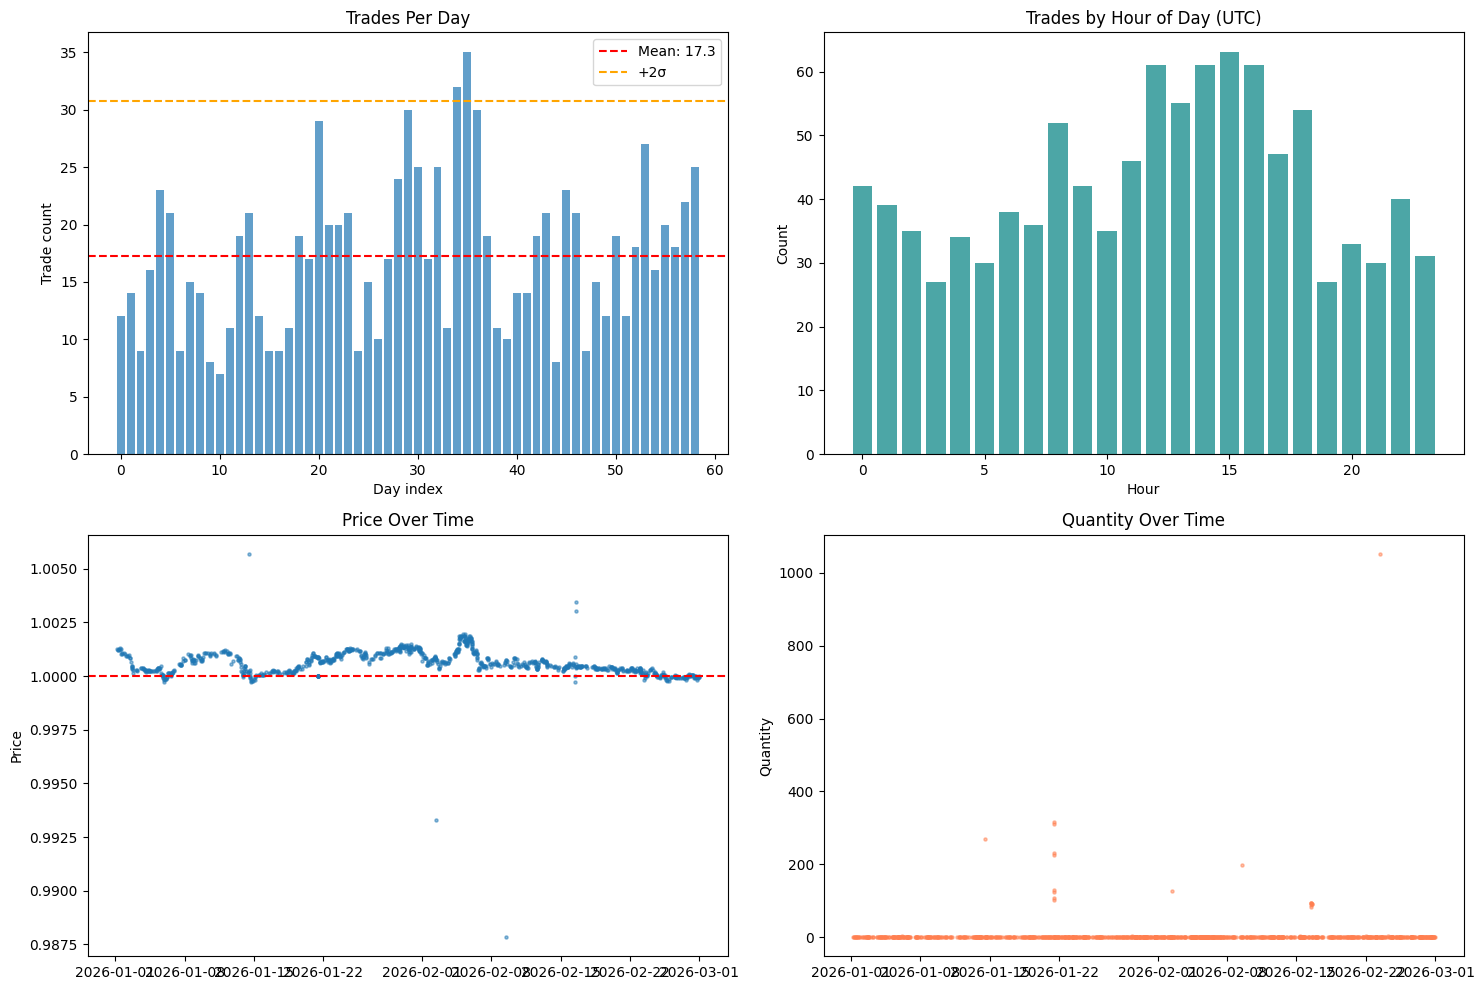

Days with z-score > 2 (unusually active):
  2026-02-04: 32 trades (z=2.19)
  2026-02-05: 35 trades (z=2.63)


In [30]:
# --- Temporal analysis ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Trades per day
daily_counts = trades.groupby('date').size()
axes[0, 0].bar(range(len(daily_counts)), daily_counts.values, alpha=0.7)
axes[0, 0].set_title('Trades Per Day')
axes[0, 0].set_xlabel('Day index')
axes[0, 0].set_ylabel('Trade count')
mean_daily = daily_counts.mean()
axes[0, 0].axhline(y=mean_daily, color='red', linestyle='--', label=f'Mean: {mean_daily:.1f}')
axes[0, 0].axhline(y=mean_daily + 2*daily_counts.std(), color='orange', linestyle='--', label='+2σ')
axes[0, 0].legend()

# Trades per hour of day
trades['hour'] = trades['timestamp'].dt.hour
hourly_counts = trades.groupby('hour').size()
axes[0, 1].bar(hourly_counts.index, hourly_counts.values, alpha=0.7, color='teal')
axes[0, 1].set_title('Trades by Hour of Day (UTC)')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Count')

# Price over time
axes[1, 0].scatter(trades['timestamp'], trades['price'], s=5, alpha=0.5)
axes[1, 0].axhline(y=1.0, color='red', linestyle='--')
axes[1, 0].set_title('Price Over Time')
axes[1, 0].set_ylabel('Price')

# Quantity over time
axes[1, 1].scatter(trades['timestamp'], trades['quantity'], s=5, alpha=0.5, color='coral')
axes[1, 1].set_title('Quantity Over Time')
axes[1, 1].set_ylabel('Quantity')

plt.tight_layout()
plt.show()

# Flag days with unusually high activity
z_threshold = 2
daily_z = (daily_counts - daily_counts.mean()) / daily_counts.std()
hot_days = daily_z[daily_z > z_threshold]
print(f"Days with z-score > {z_threshold} (unusually active):")
for day, z in hot_days.items():
    count = daily_counts[day]
    print(f"  {day}: {count} trades (z={z:.2f})")

## Step 7: Quantity Outliers + Manager Consolidation

**Key insight from the data:** Normal USDC trades are tiny (median ~0.3 USDC). Injected violations have quantities 100-1000x larger. Instead of Isolation Forest with a high contamination rate (which gives too many false positives), let's use a **z-score approach** — flag trades with extreme quantity z-scores.

Also check for **manager_consolidation** — the `manager_id` field is usually empty for normal trades. If a trade has a manager_id AND a large quantity, it could be a consolidation transaction.

In [31]:
# --- Detector 5: Extreme quantity outliers ---
trades['qty_z'] = (trades['quantity'] - trades['quantity'].mean()) / trades['quantity'].std()

# Flag trades with z-score > 3 (very extreme)
qty_outliers = trades[trades['qty_z'] > 3].copy()
print(f"=== Quantity outliers (z > 3): {len(qty_outliers)} trades ===\n")
if len(qty_outliers) > 0:
    print(qty_outliers[['trade_id', 'timestamp', 'price', 'quantity', 'qty_z', 
                         'side', 'trader_id', 'manager_id']].sort_values('qty_z', ascending=False).to_string(index=False))

# --- Detector 6: Manager consolidation ---
# Trades with a non-null manager_id are unusual
mgr_trades = trades[trades['manager_id'].notna()].copy()
print(f"\n=== Trades with manager_id (potential consolidation): {len(mgr_trades)} ===\n")
if len(mgr_trades) > 0:
    print(mgr_trades[['trade_id', 'timestamp', 'price', 'quantity', 'side', 
                       'trader_id', 'manager_id']].to_string(index=False))

=== Quantity outliers (z > 3): 9 trades ===

         trade_id                  timestamp    price    quantity     qty_z side trader_id manager_id
USDCUSDT_00001019 2026-02-23 11:00:00.000000 0.999831 1052.284019 26.190382  BUY    mgr_02     mgr_02
USDCUSDT_00001008 2026-01-21 12:10:55.335573 1.000000  315.455690  7.780450  BUY trader_02     mgr_01
USDCUSDT_00001009 2026-01-21 12:18:55.335573 1.000000  311.644842  7.685234 SELL trader_03     mgr_01
USDCUSDT_00001001 2026-01-14 11:39:00.000000 1.005697  268.848994  6.615964  BUY trader_01     mgr_01
USDCUSDT_00001005 2026-01-21 12:03:22.146995 1.000000  229.582990  5.634888 SELL trader_03     mgr_01
USDCUSDT_00001004 2026-01-21 11:59:22.146995 1.000000  226.333675  5.553703  BUY trader_02     mgr_01
USDCUSDT_00001011 2026-02-09 11:01:00.000000 0.987836  198.014104  4.846128 SELL trader_05     mgr_02
USDCUSDT_00001002 2026-01-21 11:39:58.641616 1.000000  130.593630  3.161602  BUY trader_02     mgr_01
USDCUSDT_00001010 2026-02-02 10:48:00

## Step 8: Compile USDCUSDT Submission (Precision-First)

**Lesson learned:** Our first attempt flagged 236 trades — 4.7x the total violations across ALL 8 pairs! The penalty for false positives (-2) means shotgunning destroys your score.

**New strategy:** Only submit trades we're confident about. Priority order:
1. **Peg breaks** — price deviates >0.5% from $1.00 (near-certain)
2. **Structuring** — trader_06's uniform-quantity burst (near-certain)  
3. **Manager consolidation** — trades with manager_id set (strong signal)
4. **Wash trading pairs** — rapid buy-sell from same wallet (if found)
5. **Quantity outliers** — z > 3 that aren't already captured above

In [32]:
# --- Build USDCUSDT submission (precision-first) ---
submissions = []
flagged_ids = set()

def add_flag(trade_row, vtype, remark):
    """Helper to add a flag, avoiding duplicates."""
    tid = trade_row['trade_id']
    if tid in flagged_ids:
        return
    flagged_ids.add(tid)
    submissions.append({
        'symbol': 'USDCUSDT',
        'date': trade_row['date'],
        'trade_id': tid,
        'violation_type': vtype,
        'remarks': remark
    })

# 1. Peg breaks (highest confidence)
for _, row in peg_breaks.iterrows():
    add_flag(row, 'peg_break',
             f"Price ${row['price']:.6f} deviates {row['peg_deviation']*100:.2f}% from $1.00 peg")

# 2. AML structuring (trader_06 uniform burst)
if len(structuring_wallets) > 0:
    for wallet in structuring_wallets['trader_id']:
        wt = trades[trades['trader_id'] == wallet]
        cv_val = wallet_qty[wallet_qty['trader_id'] == wallet]['qty_cv'].values[0]
        for _, row in wt.iterrows():
            add_flag(row, 'aml_structuring',
                     f"Wallet {wallet}: {len(wt)} trades with near-identical quantities (CV={cv_val:.3f}) within {wallet_qty[wallet_qty['trader_id']==wallet]['time_span_hours'].values[0]:.1f}h — smurfing pattern")

# 3. Manager-linked trades — classify more precisely
#    trader_02 buys + trader_03 sells at exact peg in rapid succession = round_trip_wash
#    mgr_02 single large trade = manager_consolidation
if len(mgr_trades) > 0:
    mgr_sorted = mgr_trades.sort_values('timestamp')
    for _, row in mgr_sorted.iterrows():
        tid = row['trader_id']
        # trader_02/trader_03 pair trading at exact $1.00 = round-trip wash
        if tid in ['trader_02', 'trader_03']:
            add_flag(row, 'round_trip_wash',
                     f"Wallets trader_02 & trader_03 trade {row['quantity']:.2f} USDC at exact peg (${row['price']:.6f}) under manager {row['manager_id']} — coordinated round-trip wash")
        # mgr_02's own trade = consolidation
        elif tid.startswith('mgr_'):
            add_flag(row, 'manager_consolidation',
                     f"Manager {tid} directly executes large {row['quantity']:.2f} USDC trade — consolidation from coordinated wallets")
        # Other manager-linked trades
        else:
            add_flag(row, 'manager_consolidation',
                     f"Trade by {tid} linked to manager {row['manager_id']}, quantity {row['quantity']:.2f} USDC — coordinated activity")

# 4. Wash trading (from strict paired detector)
if len(wash_trades) > 0:
    for _, row in wash_trades.iterrows():
        vtype = row.get('violation_type', 'wash_trading')
        add_flag(row, vtype,
                 f"Wallet {row['trader_id']}: rapid buy-sell pair with matched quantities — artificial volume")

# 5. Remaining quantity outliers (z > 3, not already flagged)
if len(qty_outliers) > 0:
    for _, row in qty_outliers.iterrows():
        if row['trade_id'] not in flagged_ids:
            if row['peg_deviation'] > 0.003:
                vtype = 'peg_break'
            else:
                vtype = 'wash_trading'
            add_flag(row, vtype,
                     f"Extreme quantity outlier: {row['quantity']:.2f} USDC (z={row['qty_z']:.1f}), price ${row['price']:.6f}")

# Build final DataFrame
sub_df = pd.DataFrame(submissions)
print(f"Total USDCUSDT flags: {len(sub_df)}")
print(f"\nBreakdown by violation type:")
print(sub_df['violation_type'].value_counts().to_string())
print(f"\n--- Full submission ---\n")
print(sub_df.to_string(index=False))

Total USDCUSDT flags: 19

Breakdown by violation type:
violation_type
round_trip_wash          8
aml_structuring          7
peg_break                3
manager_consolidation    1

--- Full submission ---

  symbol       date          trade_id        violation_type                                                                                                                     remarks
USDCUSDT 2026-01-14 USDCUSDT_00001001             peg_break                                                                               Price $1.005697 deviates 0.57% from $1.00 peg
USDCUSDT 2026-02-02 USDCUSDT_00001010             peg_break                                                                               Price $0.993304 deviates 0.67% from $1.00 peg
USDCUSDT 2026-02-09 USDCUSDT_00001011             peg_break                                                                               Price $0.987836 deviates 1.22% from $1.00 peg
USDCUSDT 2026-02-16 USDCUSDT_00001012       aml_structuring 

## Step 9: Save to submission CSV

We'll save this as our initial submission file. As we analyze more pairs, we'll append to this file.

In [33]:
# Save USDCUSDT results to CSV
sub_df.to_csv('submission.csv', index=False)
print(f"Saved {len(sub_df)} USDCUSDT flags to submission.csv")
print("\nNext up: BATUSDT analysis (Phase 1 continued)")
print("Then: systematic detection across all 8 pairs (Phase 2)")

Saved 19 USDCUSDT flags to submission.csv

Next up: BATUSDT analysis (Phase 1 continued)
Then: systematic detection across all 8 pairs (Phase 2)
